## From Kaggle: -
Data card:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

its notebooks:

- complete project
https://www.kaggle.com/code/bhartiprasad17/customer-churn-prediction

- EDA

https://www.kaggle.com/code/bandiatindra/telecom-churn-prediction

- Semi project

https://www.kaggle.com/code/tanmay111999/telco-churn-eda-cv-score-85-f1-score-80

https://www.kaggle.com/code/danishmubashar/telco-customer-churn-80-accuracy

- very good ones:

https://www.kaggle.com/code/mehmetisik/telecom-churn-prediction-learning-ml-models

https://www.kaggle.com/code/emineyetm/telco-customer-churn?scriptVersionId=112433747&cellId=24
look at: Analyze the numerical and categorical variables.In[13]

***

## From GitHub: -

https://github.com/andrewcole33/telco_churn_analysis

https://github.com/ahmedshahriar/Customer-Churn-Prediction(with Streamlit app =)

https://github.com/Rizal-A/EDA-Telco_Customer_Churn

---__-__--__--__--__--__--__--___--

## Misc.

https://towardsdatascience.com/end-to-end-machine-learning-project-telco-customer-churn-90744a8df97d/

https://www.geeksforgeeks.org/pandas/how-to-load-a-massive-file-as-small-chunks-in-pandas/

In [ ]:
import pandas

# open_cell = pandas.read_csv(r"https://drive.google.com/uc?id=1EBu0v15ZVBpMTWj7zis9G5dVesnKYO-S",header = None)

tele_churn = pandas.read_csv(r"https://drive.google.com/uc?id=1WpQ3o4vWdUb3QN6nuw4WX7pMgKNWV49t")

pandas.set_option('display.max_rows', None)
pandas.set_option('display.max_columns', None)
pandas.set_option('display.max_colwidth', None)

# express = pandas.read_csv(r"https://drive.google.com/uc?id=1Bv0q9pV0sOLHQlS7x7OaACvdEHPLRcHM")

# 1. Observing & Correcting the Dataset
> Begin by observing the structure of the dataset—its size, types of variables, and whether the data is categorical or numerical.


In [ ]:
print(f'Memory: {tele_churn.memory_usage(deep=True).sum()/1e6:.1f} MB')
var_classes = """
#  Customer identifiers
   "user_id", "region"
#  Customer behaviour
 "tenure", "montant", "frequence_rech", "revenue", "arpu_segment", "frequence", "data_volume", "on_net", "orange", "tigo",  "zone1", "zone2", "mrg", "regularity", "top_pack", "freq_top_pack"
#  Region-level network KPIs  (ADM1)
 "region_tower_count", "region_avg_range", "region_avg_samples", "region_avg_signal", "region_coverage_index", "region_signal_strength_index", "region_network_quality_score"
#  Department-level network KPIs  (ADM2, aggregated to region)
 "department_signal_strength_index", "department_network_quality_score",  "department_coverage_index"
#  Arrondissement-level network KPIs  (ADM3, aggregated to region)
 "arr_signal_strength_index", "arr_network_quality_score", "arr_coverage_index"
#  Target
   "churn"

""".split('\n')

var_classes = {k:v for k,v in zip([cls[3:] for cls in var_classes if '#' in cls], [var.strip().replace('"','').split(', ') for var in var_classes if '",' in var])}

print(tele_churn['user_id'].dtype)
for k,attr in var_classes.items():

  var_classes[k] = list(map(lambda x: (x.strip(),'categorical') if tele_churn[x.strip()].dtype == 'object'  else (x.strip(),'numerical'),[item for item in attr if len(item) > 1]))

print(var_classes)
print(tele_churn.dtypes)

Memory: 51.9 MB
object
{'Customer identifiers': [('user_id', 'categorical'), ('region', 'categorical')], 'Customer behaviour': [('tenure', 'categorical'), ('montant', 'numerical'), ('frequence_rech', 'numerical'), ('revenue', 'numerical'), ('arpu_segment', 'numerical'), ('frequence', 'numerical'), ('data_volume', 'numerical'), ('on_net', 'numerical'), ('orange', 'numerical'), ('tigo', 'numerical'), ('zone1', 'numerical'), ('zone2', 'numerical'), ('mrg', 'categorical'), ('regularity', 'numerical'), ('top_pack', 'categorical'), ('freq_top_pack', 'numerical')], 'Region-level network KPIs  (ADM1)': [('region_tower_count', 'numerical'), ('region_avg_range', 'numerical'), ('region_avg_samples', 'numerical'), ('region_avg_signal', 'numerical'), ('region_coverage_index', 'numerical'), ('region_signal_strength_index', 'numerical'), ('region_network_quality_score', 'numerical')], 'Department-level network KPIs  (ADM2, aggregated to region)': [('department_signal_strength_index', 'numerical'), ('

# 2. Identifying [adjacent] Missing Values
> Use summary statistics and visualizations to identify any gaps or missing values in the dataset, helping you decide how to handle them during analysis.


In [ ]:
print(tele_churn.isna().sum().sum())#.value_counts())

tele_NAs = tele_churn.isna() #NOTE: used more than 1 time rightaway.

missing = pandas.DataFrame({
    "messy_types": tele_churn.dtypes,
    "Missing %": tele_NAs.mean().mul(100).round(2),
    "reference": tele_churn.apply(lambda x: x.index[x.isna()].tolist()) ,# Much better than using MapReduce at that case =)
}).sort_values("Missing %", ascending=False)
cat_missing,num_missing, no_missing = missing[(missing["Missing %"] > 0) & (missing['messy_types'] == 'object')], missing[(missing["Missing %"] > 0) & (missing['messy_types'] != 'object')], missing[missing["Missing %"] == 0].index
print(sum(missing['Missing %']),'\nNo missings: ',no_missing)

776600
776.63 
No missings:  Index(['user_id', 'regularity', 'mrg', 'tenure', 'churn'], dtype='object')


In this specific snippet, Pandas uses the **Index Alignment** property of the `Series` objects you are passing into the dictionary.

When you create a DataFrame by passing a dictionary of Series, Pandas looks at the **index** of each Series to determine the rows of the new DataFrame.

### 1. The Logic Flow
Here is the step-by-step "governance" of how that index was formed:

* **Step 1: The Source Statistics:** When you call `tele_churn.isna().sum()`, `tele_churn.isna().mean()`, or `tele_churn.dtypes`, the result of each operation is a **Pandas Series**.
* **Step 2: The Series Index:** For these specific operations, the index of the resulting Series is automatically set to the **column names** of the original `tele_churn` DataFrame.
* **Step 3: Dictionary Alignment:** When you wrap these three Series in a dictionary `{...}` and pass them to `pd.DataFrame()`, Pandas aligns them by their indices. Since all three have the exact same index (the original column names), that shared index becomes the index of the new `missing` DataFrame.



---

### 2. Breakdown of the "Ancestry"
| Operation | Result Type | Index | Values |
| :--- | :--- | :--- | :--- |
| `tele_churn.isna().sum()` | Series | Column Names | Integer counts |
| `tele_churn.isna().mean()` | Series | Column Names | Floating-point percentages |
| `tele_churn.dtypes` | Series | Column Names | Dtype objects |

Because the **Index** of these three Series contains the names of your original columns, those names "flow" into the new DataFrame as its labels.

---

### 3. The "In-Place" Indexing Concept
In Java terms, you can think of this like a **TreeMap** where the keys are the column names. When you merge multiple TreeMaps into a table, the keys are extracted to form the leftmost vertical axis (the Index).

If you wanted the column names to be an actual data column instead of the index, you would have to explicitly call `.reset_index()` on the resulting `missing` DataFrame:

```python
# Moves the Column Names from the Index into a column named 'index'
missing = missing.reset_index()
```

### 4. Why this is "Good Governance"
By using the column names as the index, Pandas ensures that even if the columns were somehow reordered in one of your calculations, the data would still "snap" to the correct row because it matches by **label**, not by **position**. This prevents the "Value Conflict" of accidentally putting a `dtype` next to the wrong `Missing #` count.

In [ ]:
print(tele_churn.shape)#() TypeError: 'numpy.ndarray' object is not callable
empty_rows_set = set(missing['reference'].iloc[0])
for column in range(1,len(missing.index)-5):#skipping the NoMisses
  print(missing['Missing %'].iloc[column],missing['reference'].iloc[column][0:5])
  empty_rows_set = empty_rows_set.intersection(set(missing['reference'].iloc[column]))

# empty_rows_set = set()
# for record in range(len(tele_churn.values)):
#   not_empty = True
#   while not_empty:
#     pass
#     if tele_churn[m]
# /tmp/ipykernel_5816/1498597929.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated.
# In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


(100000, 32)
92.09 [0, 1, 2, 3, 4]
59.63 [2, 3, 4, 5, 6]
49.19 [4, 8, 15, 16, 17]
41.74 [2, 4, 7, 14, 16]
41.74 [2, 4, 7, 14, 16]
41.38 [2, 3, 4, 12, 13]
39.16 [1, 2, 5, 16, 23]
36.34 [1, 13, 14, 16, 17]
34.94 [2, 4, 14, 16, 19]
34.94 [2, 4, 14, 16, 19]
33.52 [2, 4, 14, 16, 17]
33.52 [2, 4, 14, 16, 17]
33.52 [2, 4, 14, 16, 17]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]
8.57 [9, 20, 40, 50, 51]


True


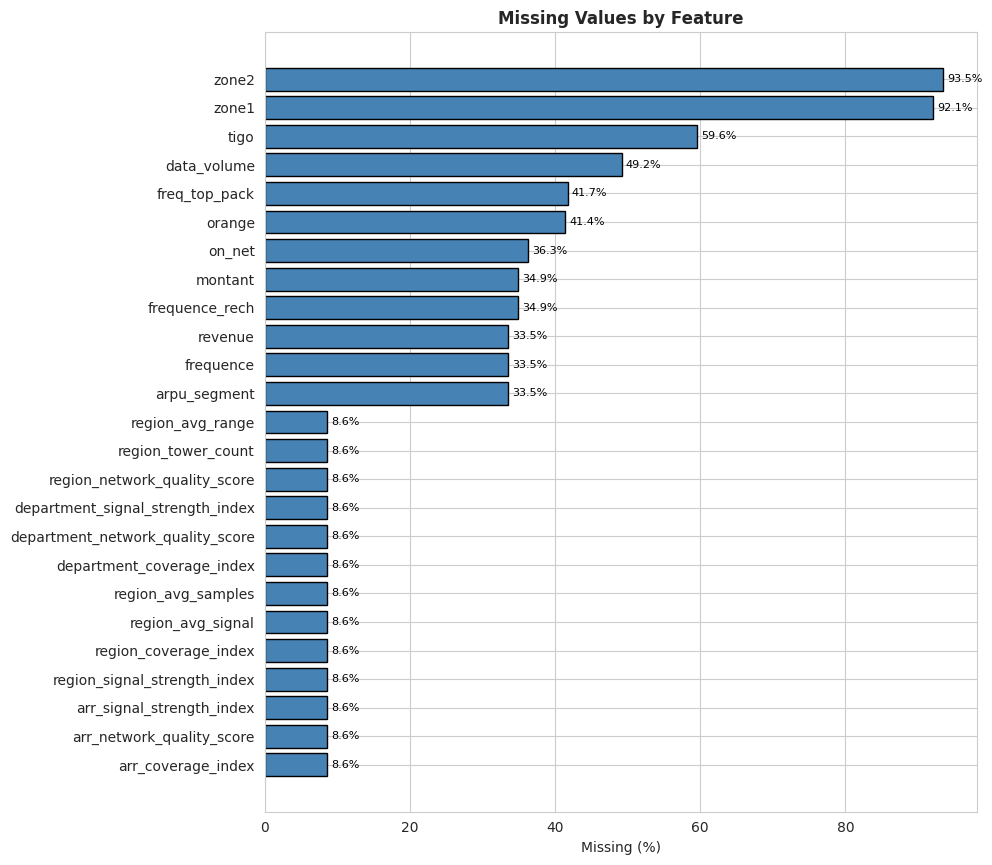


After custom context:  False
False


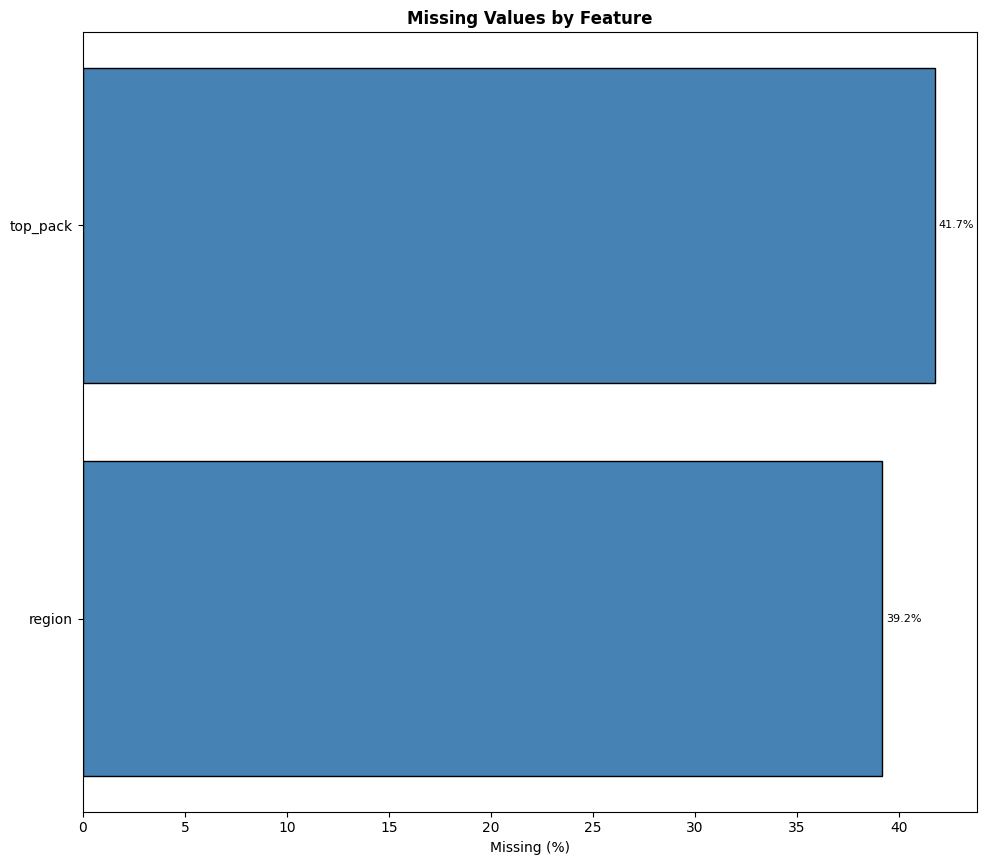


After custom context:  False


In [ ]:
# missing.plot(kind = "barh",) #.isna().sum()
import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("whitegrid"):
  # plt.rcParams['axes.grid'] = False
  fig, ax = plt.subplots(figsize=(10, max(4, len(num_missing) * 0.35)))
  bars = ax.barh(num_missing.index, num_missing["Missing %"], color="steelblue", edgecolor="black")
  print(plt.rcParams['axes.grid'])

ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)

ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Feature", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nAfter custom context: ",plt.rcParams['axes.grid'])


fig, ax = plt.subplots(figsize=(10, max(4, len(num_missing) * 0.35)))
bars = ax.barh(cat_missing.index, cat_missing["Missing %"], color="steelblue", edgecolor="black")
print(plt.rcParams['axes.grid'])

ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)

ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Feature", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nAfter custom context: ",plt.rcParams['axes.grid'])


In the code snippet you provided, the line doing the heavy lifting is `sns.set(style="whitegrid")`.

Think of **Matplotlib** as the raw engine and chassis of a car, and **Seaborn** as a high-end body kit and interior upgrade. Seaborn doesn't actually replace Matplotlib; it **intercepts its default configuration parameters** (known as `rcParams`) to make things look "modern" right out of the box.

Here is how that "takeover" works technically:

### 1. Overwriting the `rcParams`
Matplotlib has a massive hidden dictionary of settings called `rcParams`. This dictionary controls everything: font sizes, line thicknesses, grid colors, and background hues.
* When you call `sns.set()`, Seaborn essentially performs a "bulk update" on that dictionary.
* It changes the default gray/white background to a specific hex code and turns on the grid lines.


### 2. Semantic Mapping vs. Manual Plotting
Notice in your code you are still using `ax.barh(...)`, which is a pure Matplotlib command.
Because Seaborn has already "poisoned the well" (in a good way) by updating the global styles, Matplotlib now draws its bars using Seaborn's color palette (`steelblue`) and font styling, even though you didn't explicitly tell Matplotlib to use those colors.

---

### 3. Key Upgrades Seaborn applied to your Chart:
Looking at your specific output image, here is what Seaborn "forced" onto Matplotlib:

| Feature | Matplotlib Default (Classic) | Seaborn `whitegrid` |
| :--- | :--- | :--- |
| **Background** | Harsh White | Subtle light gray/off-white |
| **Grid Lines** | None (Usually) | Soft white horizontal/vertical lines |
| **Spines** | Black boxes on all 4 sides | Removed top and right "spines" for a cleaner look |
| **Color** | Standard `'b'` (Primary Blue) | Desaturated `'steelblue'` (Easier on the eyes) |
***
### A Quick Tip for "Governance"
If you want to use Seaborn's styles but don't want it to affect *every* plot in your notebook (to avoid "global state" pollution), you can use a context manager:

```python
# Style only applies to the code inside this block
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots()
    ax.barh(missing.index, missing["Missing %"])
```

**Notice how your chart is sorted?** It makes those missing values for `zone2` and `zone1` look incredibly high (~93%). Does that align with how you expected the data to be distributed, or does it suggest a systematic issue with how those specific features are being collected?

In [ ]:
#Na* make big troubles in the next phases, so I decided to deal with them firstly!
#---------------------
# [col for col in missing.index if missing['Missing %'] < 25]#ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().


semi_cleaned_teleset = tele_churn.dropna(subset=[col for col in missing[missing['Missing %'].between(1,25) ].index])
print(len(semi_cleaned_teleset.values), len(tele_churn.values))
# print(tele_churn[[col for col in missing[missing['Missing %'] > 25 or missing['Missing %'] <75].index]].describe())#ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
print(tele_churn[[col for col in missing[missing['Missing %'].between(25,75)].index]].describe(include = 'all'))
#After overseeing the descriptive table, filling with mode & median accordingly
cat_mod = {k:v for k,v in zip(cat_missing.index,[tele_churn[id].mode()[0] for id in cat_missing.index])}
cat_mod.update({k:v for k,v in zip(num_missing.index,[tele_churn[id].median() for id in num_missing.index])})
# print((tele_churn['region'].mode())
TBR = [col for col in missing[missing['Missing %'] .between(1,25)].index]+[col for col in cat_mod.keys()]
print('user_id' in TBR);print(missing[missing['Missing %'].between(5,25) ].index)
semi_cleaned_teleset = semi_cleaned_teleset.fillna(cat_mod).rename(columns = {k:v for k,v in zip(TBR,[col + '_CLEANED' for col in TBR])})
#{1:3}.

# print(tele_churn[[col for col in missing[missing['Missing %'].between(25,75)].index]].mode())

# print(semi_cleaned_teleset[[col for col in missing.index]].isna().sum()) #checking the removal of few NAs


91430 100000
                tigo    data_volume  freq_top_pack               top_pack  \
count   40369.000000   50813.000000   58264.000000                  58264   
unique           NaN            NaN            NaN                     90   
top              NaN            NaN            NaN  All-net 500F=2000F;5d   
freq             NaN            NaN            NaN                  14703   
mean       23.241844    3385.929546       9.295860                    NaN   
std        64.455804   12533.674332      12.806149                    NaN   
min         0.000000       0.000000       1.000000                    NaN   
25%         2.000000       0.000000       2.000000                    NaN   
50%         6.000000     256.000000       5.000000                    NaN   
75%        20.000000    2927.000000      12.000000                    NaN   
max      1963.000000  926547.000000     560.000000                    NaN   

              orange region        on_net        montant  freq

By default, **`df.describe()`** acts as a "filter" that prioritizes numerical data. If your DataFrame contains a mix of numbers and strings (categorical data), Pandas automatically selects only the numeric columns to prevent "Value Conflicts" in the statistical output.

Here is how you can "govern" the `describe()` function to include everything:

---

### 1. The Default Behavior (Numeric Only)
When your DataFrame is a "mixed-type" container, Pandas assumes you want to calculate mathematical stats (mean, std, etc.). Since it can't calculate the "average" of a string like `'zone1'`, it simply excludes those columns from the summary.



### 2. Including Everything: `include='all'`
If you want a single report that covers both your skewed numerical data (`data_volume`) and your categorical features (like `top_pack`), you must pass the `include` parameter.

```python
# This forces Pandas to show every column, regardless of type
df.describe(include='all')
```

**The Output Paradox:**
When you use `include='all'`, Pandas creates a "Super-Table" that includes rows for both numeric and categorical stats. Because some stats don't apply to both types, you will see many **`NaN`** values:
* **Numerical columns** will have `NaN` for `unique`, `top`, and `freq`.
* **Categorical columns** will have `NaN` for `mean`, `std`, `min`, and the percentiles.

---

### 3. Categorical-Only Summary
If you are specifically performing Feature Engineering (FE) on your categories (like checking the cardinality of `freq_top_pack`), you can isolate just the non-numeric types:

```python
# 'O' stands for Object (Strings)
df.describe(include=['O'])
```

**What the Categorical Stats Mean:**
| Metric | Meaning |
| :--- | :--- |
| **count** | Number of non-null entries. |
| **unique** | Number of distinct categories (Cardinality). |
| **top** | The **Mode** (the most frequent value). |
| **freq** | How many times the "top" value occurred. |



---

### 4. Technical Governance: The `exclude` Parameter
In a Java-style architecture, you might want to "Blacklist" certain types instead of "Whitelisting" them. You can tell Pandas to describe everything *except* specific types:

```python
# Describe everything except the floating-point numbers
df.describe(exclude=[np.number])
```

### Why this matters for your `tele_churn` Project:
Looking at your previous code where you filtered columns based on `Missing %`, remember that **`df.describe()`** only gives you the "survivors" of the numeric filter. If you have categorical columns with 0% missing values, they won't even show up in your current `print(tele_churn[...].describe())` unless you explicitly include them.

**Would you like to see how to use the `unique` and `freq` counts from a categorical `describe()` to identify "Low Variance" features that should be dropped before Feature Engineering?**

Based on the `describe()` output in your second image, **yes—every single one of these columns is heavily right-skewed.**

In your "Java-style" mental model, you can think of this as a **Validation Check**: if the data were balanced (Normal), the Mean would be the perfect representative of the "Local" behavior. Instead, these stats show a massive **Value Conflict** where a few "Power Users" are inflating the global averages.

---

### The Evidence in your Stats
To confirm right-skewness at a glance, look at these two specific relationships:

#### 1. Mean > 50% (Median)
This is the "Golden Rule" of skewness.
* **`data_volume`**: The Mean is **3,385**, but the Median is only **256**. The average is **13x higher** than the middle value!
* **`tigo`**: Mean is **23**, Median is **6**.
* **`on_net`**: Mean is **279**, Median is **27**.

#### 2. The "Max" vs. the Rest
Look at the distance between the **75%** mark and the **Max**.
* In **`data_volume`**, 75% of your users are under **2,927**, but the Max is a staggering **926,547**.
* This "Long Tail" is pulling the Mean far to the right, away from the bulk of the population.


---

### Analysis of the Financial Column (Image 1)
Looking at your first image (the one with the `215,0712,8000` numbers and the `-27.272%` percentage), this data is also a prime candidate for right-skewness once cleaned:
* You have many multi-million/billion values.
* You have a few tiny values (like `0.268` and `1.151`).
* **The Paradox:** The presence of that percentage (`-27.272%`) and the hyphens (`-`) are "poisoning" your column as an **Object** type. Until you strip those and convert to numeric, you won't be able to run `.describe()` to see the skewness.

---

### Why this matters for your "Missing Values" Logic
Since you are currently filtering columns based on `Missing %` (your code shows `< 25` and `.between(25, 75)`), the skewness tells you a story:
* **High Skew + High Missing %:** If a column like `zone1` is 93% missing and the remaining 7% is right-skewed, that 7% might be an **unrepresentative sample**. It's not just "missing data"; it's a "biased subset."

### Quick Governance Table for your Stats

| Column | Median (50%) | Mean | Skew Direction | Severity |
| :--- | :--- | :--- | :--- | :--- |
| **tigo** | 6 | 23 | Right | Moderate |
| **data_volume**| 256 | 3,385 | Right | **Extreme** |
| **on_net** | 27 | 279 | Right | **Extreme** |
| **montant** | 3,000 | 5,529 | Right | Moderate |

In these cases, if you were to write a Java middleware to process this data, you should probably use the **Median** for your business logic thresholds rather than the **Mean**, as the Mean is being "lied to" by the outliers.

Does this confirm what you were seeing in your preliminary analysis of the `tele_churn` dataset?

# DONE: """Correcting... frocibly floated into actual num_type"""


Removing observations with missing values is a quick and dirty way to deal with missing data, but this can introduce bias to your data if the values are not missing at random.

In [ ]:
semi_cleaned_teleset.describe().T

,count,mean,std,min,25%,50%,75%,max
montant_CLEANED,91430.0,4571.391381,5828.962759,50.000000,2000.000,3000.000000,4.450000e+03,2.265500e+05
frequence_rech_CLEANED,91430.0,9.866160,10.857824,1.000000,4.000,7.000000,9.000000e+00,1.320000e+02
revenue_CLEANED,91430.0,4593.968632,5991.247893,1.000000,1959.000,3000.000000,4.499000e+03,2.334130e+05
arpu_segment_CLEANED,91430.0,1531.327026,1997.079117,0.000000,653.000,1000.000000,1.500000e+03,7.780400e+04
frequence_CLEANED,91430.0,12.201105,12.123354,1.000000,6.000,9.000000,1.300000e+01,9.100000e+01
data_volume_CLEANED,91430.0,1831.680017,9340.532471,0.000000,256.000,256.000000,2.560000e+02,9.265470e+05
on_net_CLEANED,91430.0,178.585869,685.196075,0.000000,12.000,27.000000,5.000000e+01,3.668700e+04
orange_CLEANED,91430.0,66.080411,157.846050,0.000000,21.000,28.000000,3.800000e+01,5.299000e+03
tigo_CLEANED,91430.0,12.114590,39.749965,0.000000,6.000,6.000000,6.000000e+00,1.963000e+03
zone1_CLEANED,91430.0,1.563426,10.135605,0.000000,1.000,1.000000,1.000000e+00,1.204000e+03


In [ ]:
numerical_cols = [column for column in semi_cleaned_teleset.keys() if str(semi_cleaned_teleset[column].dtype) != 'object']
for attr in numerical_cols:
  it_is_real = True
  for j in range(len(semi_cleaned_teleset[attr])):
    if semi_cleaned_teleset[attr].iloc[j] - int(semi_cleaned_teleset[attr].iloc[j]):
      it_is_real = False
      print(f"{attr} is definitely float!")
      break
  if it_is_real:
    print(f"{attr} has no decimals!")
    semi_cleaned_teleset[attr] = semi_cleaned_teleset[attr].astype(int)


montant_CLEANED has no decimals!
frequence_rech_CLEANED has no decimals!
revenue_CLEANED has no decimals!
arpu_segment_CLEANED has no decimals!
frequence_CLEANED has no decimals!
data_volume_CLEANED has no decimals!
on_net_CLEANED has no decimals!
orange_CLEANED has no decimals!
tigo_CLEANED has no decimals!
zone1_CLEANED has no decimals!
zone2_CLEANED has no decimals!
regularity has no decimals!
freq_top_pack_CLEANED has no decimals!
region_tower_count_CLEANED has no decimals!
region_avg_range_CLEANED is definitely float!
region_avg_samples_CLEANED is definitely float!
region_avg_signal_CLEANED has no decimals!
region_coverage_index_CLEANED has no decimals!
region_signal_strength_index_CLEANED has no decimals!
region_network_quality_score_CLEANED is definitely float!
department_signal_strength_index_CLEANED has no decimals!
department_network_quality_score_CLEANED is definitely float!
department_coverage_index_CLEANED has no decimals!
arr_signal_strength_index_CLEANED has no decimals!

In [ ]:
semi_cleaned_teleset.dtypes

,0
user_id,object
region_CLEANED,object
tenure,object
montant_CLEANED,int64
frequence_rech_CLEANED,int64
revenue_CLEANED,int64
arpu_segment_CLEANED,int64
frequence_CLEANED,int64
data_volume_CLEANED,int64
on_net_CLEANED,int64


# 3. Categorizing Data
> Classify the dataset into meaningful categories, distinguishing between numerical and categorical variables, or even between discrete and continuous data types.


In [ ]:
categorical_cols= [column for column in semi_cleaned_teleset.keys() if str(semi_cleaned_teleset[column].dtype) == 'object']
discrete_cols = [column for column in semi_cleaned_teleset.keys() if str(semi_cleaned_teleset[column].dtype) == 'int64']
continuous_cols = set(numerical_cols).difference(set(discrete_cols))
print(len(numerical_cols));print(categorical_cols); print(len(discrete_cols));print(len(continuous_cols));

27
['user_id', 'region_CLEANED', 'tenure', 'mrg', 'top_pack_CLEANED']
22
5


In [ ]:
#TODO: decompose "tenure" to duration_level, duration(int, where >24 is valued 25 at least)
print('Duplicates:', semi_cleaned_teleset.duplicated().sum())

Duplicates: 0


# 4. Determining the Shape of Data (*UV analysis*)
> Analyze the distribution of variables by looking for skewness, kurtosis, and other factors that indicate the shape of the data.


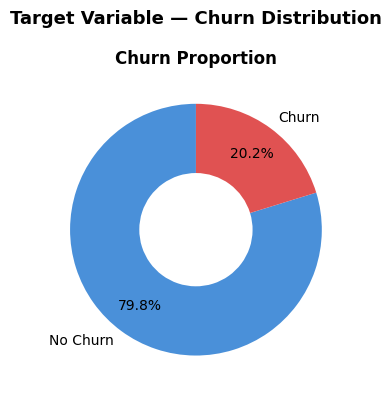

churn
0    79.8
1    20.2
Name: proportion, dtype: float64

Churn rate: 20.2%  →  IMBALANCED. The team leader said*


In [ ]:
churn_counts = semi_cleaned_teleset['churn'].value_counts()
churn_pct    = semi_cleaned_teleset['churn'].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots( figsize=(11, 4))

# Bar chart
colors = ["#4A90D9", "#E05252"]
# axes[0].bar(["No Churn (0)", "Churn (1)"], churn_counts.values, color=colors, edgecolor="white")
# for i, (cnt, pct) in enumerate(zip(churn_counts, churn_pct)):
#     axes[0].text(i, cnt + 300, f"{pct}%", ha="center", fontweight="bold")
# axes[0].set_title("Churn Count", fontweight="bold")
# axes[0].set_ylabel("Customers")

# Pie chart
axes.pie(churn_counts, labels=["No Churn", "Churn"], colors=colors,
            autopct="%1.1f%%", startangle=90, pctdistance=0.75,
            wedgeprops=dict(width=0.55))   # donut style
axes.set_title("Churn Proportion", fontweight="bold")

plt.suptitle("Target Variable — Churn Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(churn_pct)
print(f"\nChurn rate: {churn_pct[1]:.1f}%  →  "
      f"{'Balanced' if 30 <= churn_pct[1] <= 70 else 'IMBALANCED. The team leader said*'}")


# Please, Omar: check for zone 1, 2 NAs

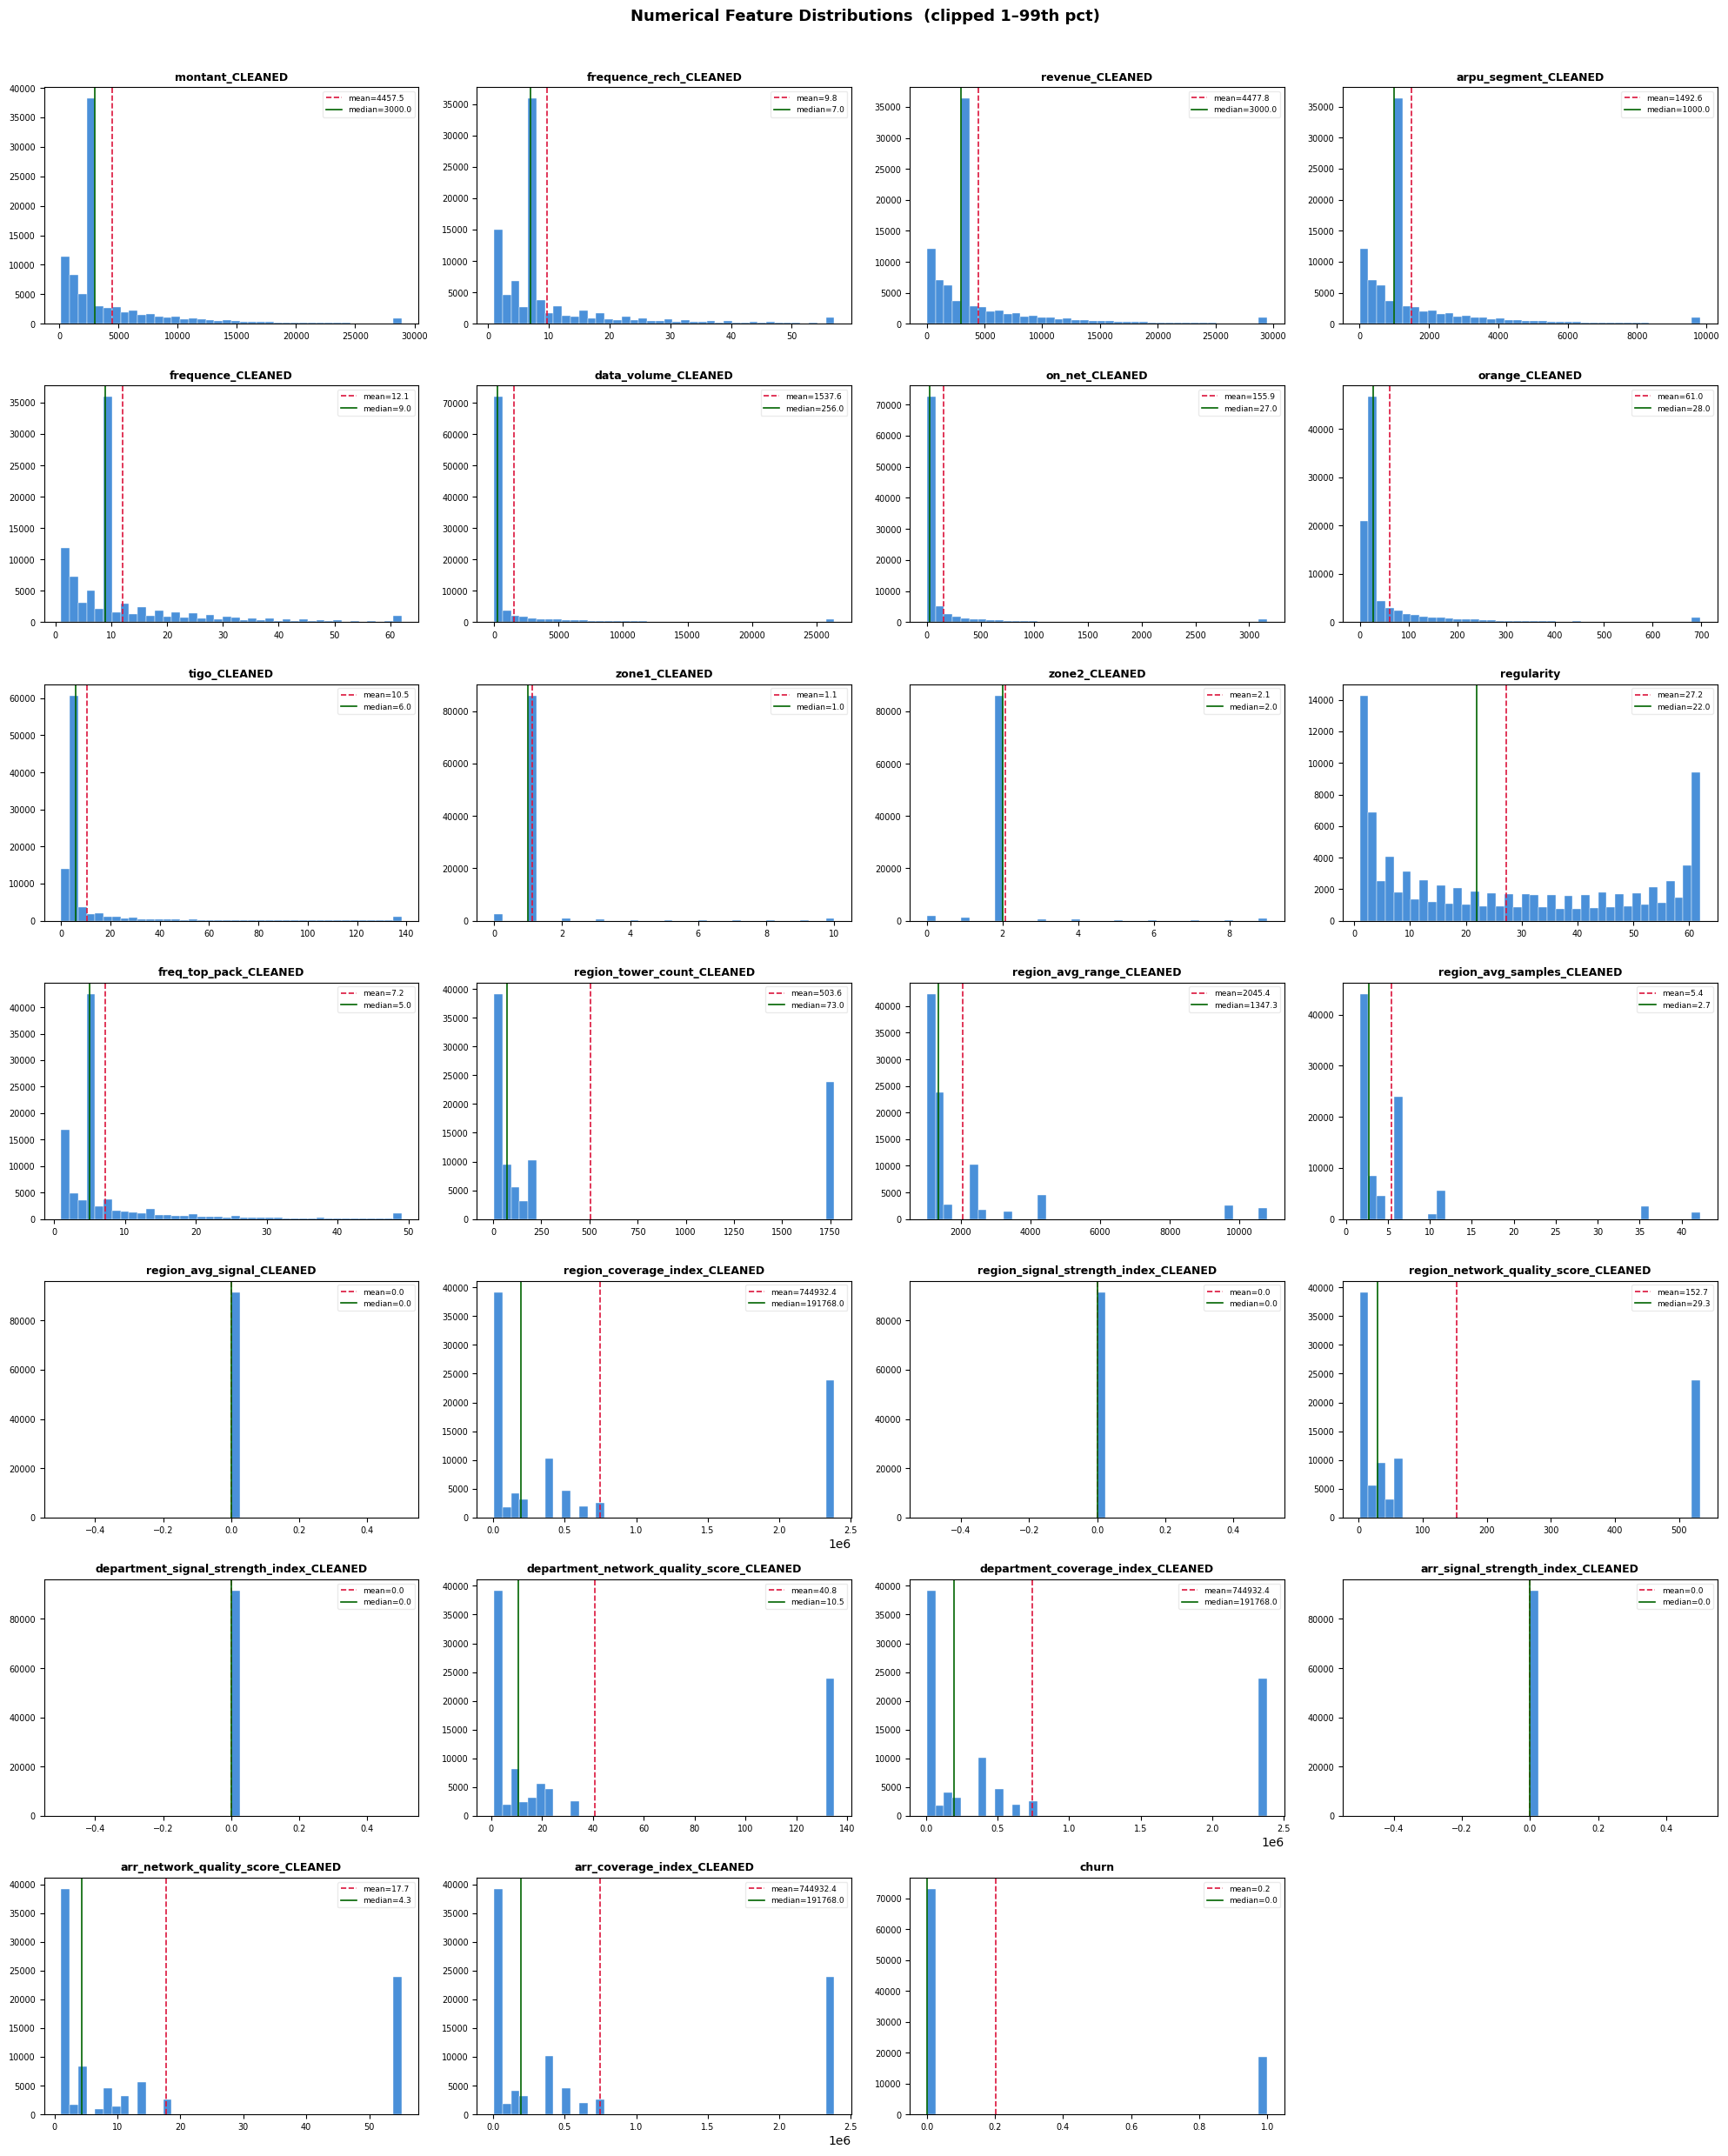

In [ ]:
# Use 4-column grid
n_cols  = 4
n_rows  = (len(numerical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    data = semi_cleaned_teleset[col].dropna()

    # Clip extreme outliers for visual clarity (keep 1st–99th percentile)
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    clipped  = data.clip(p1, p99)

    axes[i].hist(clipped, bins=40, color="#4A90D9", edgecolor="white", linewidth=0.3)

    # Overlay mean & median lines
    axes[i].axvline(clipped.mean(),   color="crimson",    ls="--", lw=1.2,
                    label=f"mean={clipped.mean():.1f}")
    axes[i].axvline(clipped.median(), color="darkgreen", ls="-",  lw=1.2,
                    label=f"median={clipped.median():.1f}")

    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)
    axes[i].legend(fontsize=6.5, framealpha=0.4)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Feature Distributions  (clipped 1–99th pct)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

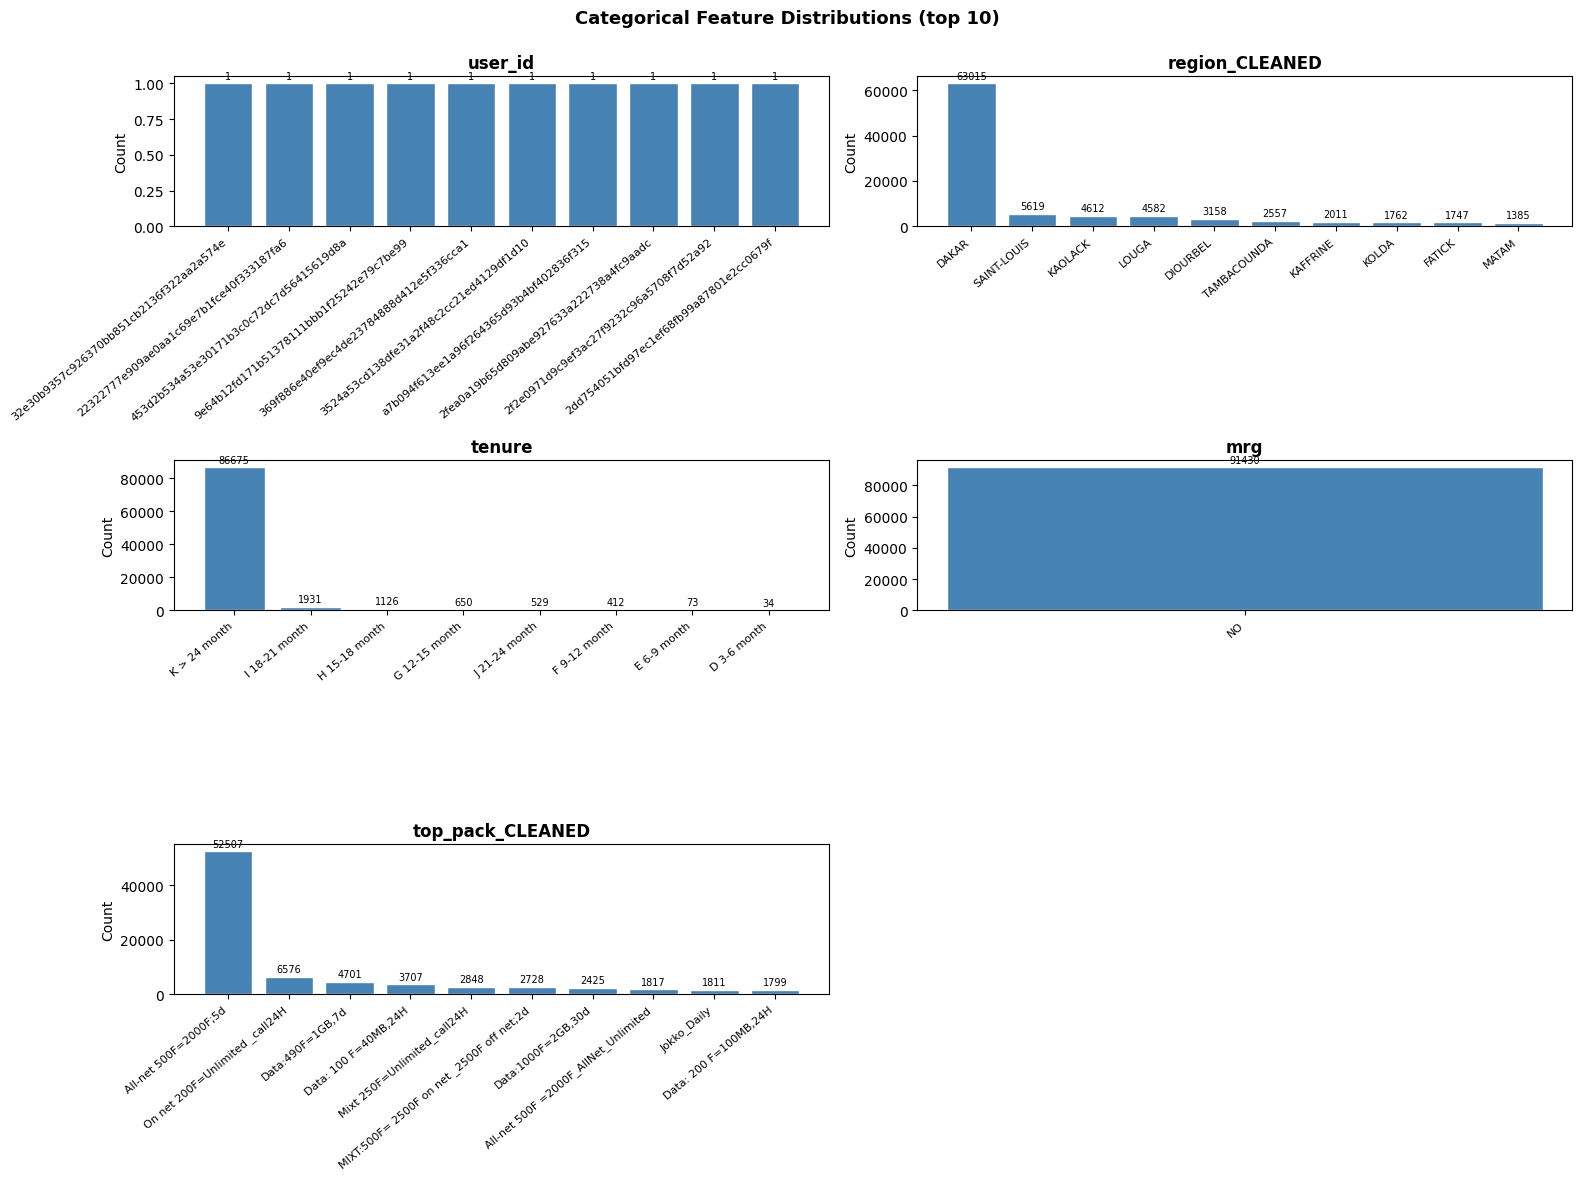

In [ ]:
top_n = {'top_pack': 10}

n_cols = 2
n_rows = (len(categorical_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    n = top_n.get(col, 10)  # default top 10
    counts = semi_cleaned_teleset[col].value_counts().head(n)
    bars   = axes[i].bar(range(len(counts)), counts.values,
                         color="steelblue", edgecolor="white")
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=40, ha="right", fontsize=8)
    axes[i].set_title(f"{col}", fontweight="bold")
    axes[i].set_ylabel("Count")
    axes[i].bar_label(bars, fmt="%d", padding=2, fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Feature Distributions (top 10)\n", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 5. Identifying Relationships (MV analysis)
> Explore correlations between variables by examining scatter plots, correlation matrices, and covariance to uncover potential causal links.


In [ ]:
BIVARIATE_COLS = ["montant", "revenue", "frequence", "data_volume",
                  "regularity", "freq_top_pack", "on_net", "orange"]

BIVARIATE_COLS = ["montant", "revenue", "frequence", "data_volume",
                  "regularity", "freq_top_pack", "on_net", "orange"]

N_COLS_BI = 4
n_rows_bi  = (len(BIVARIATE_COLS) + N_COLS_BI - 1) // N_COLS_BI

fig, axes = plt.subplots(n_rows_bi, N_COLS_BI, figsize=(20, n_rows_bi * 4))
axes = axes.flatten()

palette = {0: "#4A90D9", 1: "#E05252"}

for i, col in enumerate(BIVARIATE_COLS):
    sub = semi_cleaned_teleset[[col, 'churn']].dropna()
    p1, p99 = sub[col].quantile(0.01), sub[col].quantile(0.99)
    sub = sub[sub[col].between(p1, p99)]

    # Force churn to int to match the palette keys exactly
    sub['churn'] = sub['churn'].astype(int)

    # Use Boxplot to show (Median, IQR, Range)
    sns.pairplot(data=sub, #x='churn',
                #  y=col,
                 hue='churn', #palette=palette,
                # ax=axes[i],
                #  linewidth=0.8, #fliersize=0,
                    # width=0.5,
                    # legend=False
                 )

    # Use Stripplot to show (Density, Clusters, Gaps).
    # Sampling 500-1000 points shows the 'spread' without overplotting the whole 100k
    sns.pairplot(
    data=sub.sample(min(len(sub), 500)), # Sample to avoid a mess
    # x='churn',
    # y=col,
    # color="black",
    # alpha=0.3,
    height=2, #size: deprecated in pairPlote
    # ax=axes[i]
    )

    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Churn", "Churn"])
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_xlabel(None)
    axes[i].set_ylabel(None)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Features vs Churn\n", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

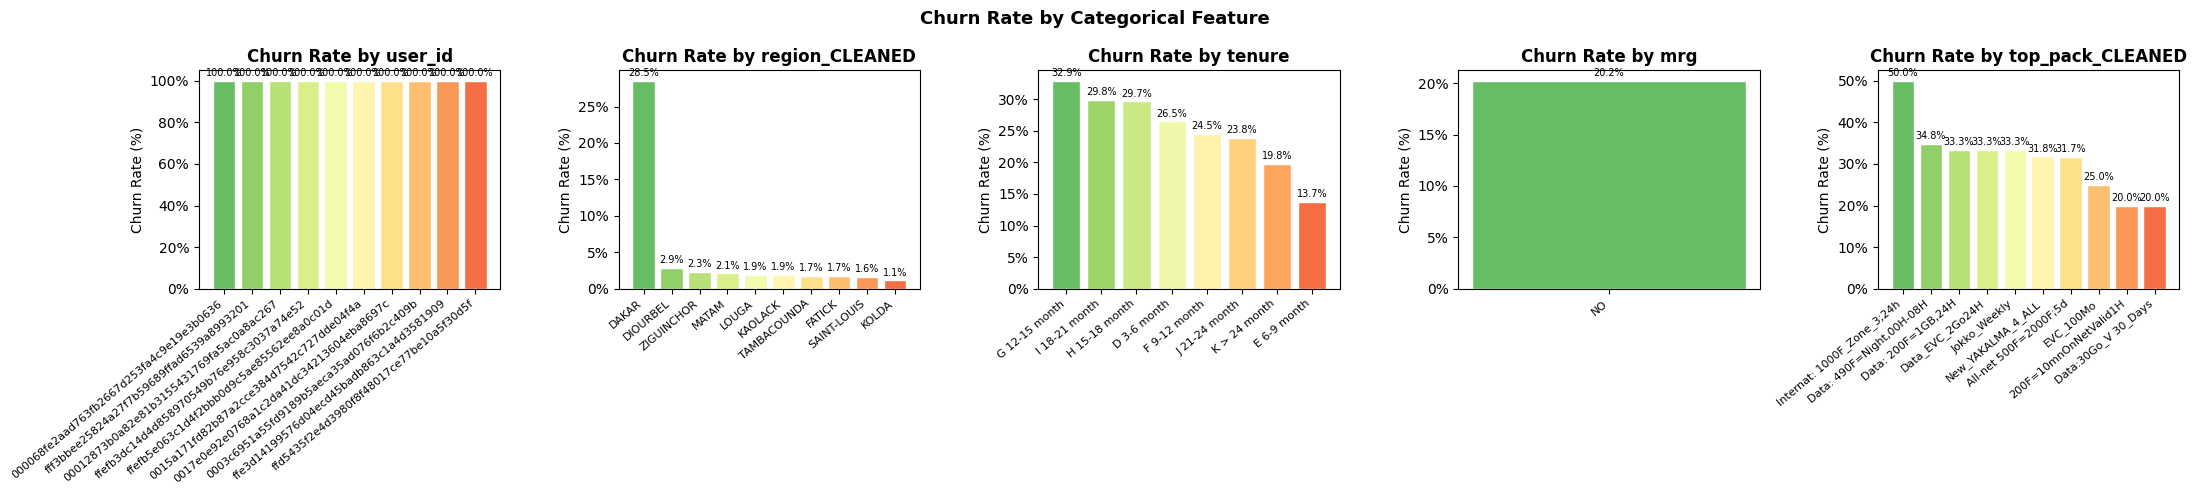

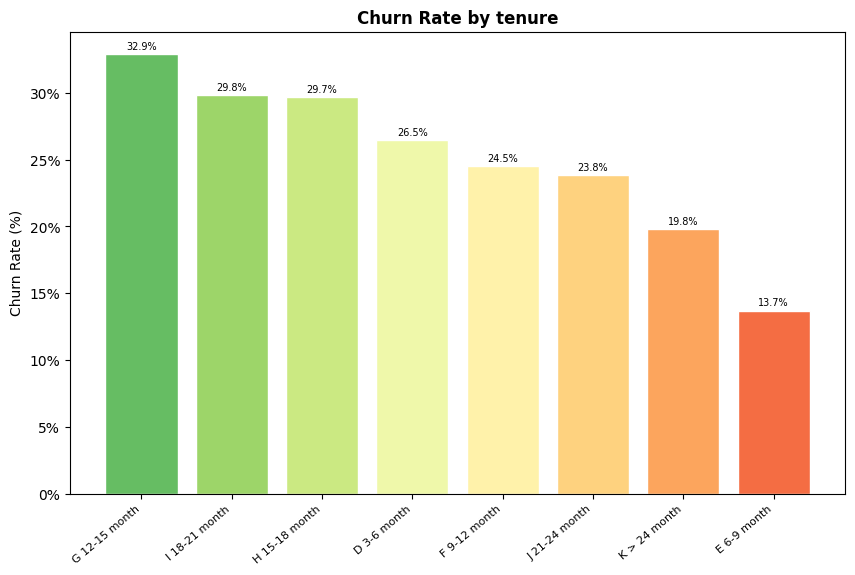

In [ ]:
import matplotlib.ticker as mticker
import numpy

# 1. Fix Column Headers
semi_cleaned_teleset.columns = semi_cleaned_teleset.columns.str.strip().str.replace('\t', '')

# 2. Clean Object/String data without breaking actual NaNs
# We target only object columns to preserve numeric/datetime integrity
obj_cols = semi_cleaned_teleset.select_dtypes(include=['object']).columns

semi_cleaned_teleset[obj_cols] = (
    semi_cleaned_teleset[obj_cols]
    .apply(lambda x: x.str.strip().str.replace('\t', ''))
    .replace(['', 'nan', 'None'], numpy.nan) # Convert empty/garbage strings back to true Nulls
)

# 3. Synchronize your BIVARIATE_COLS list
BIVARIATE_COLS = [c.strip().replace('\t', '') for c in BIVARIATE_COLS]

###
def plot_cat_vs_churn(col, top_n=15, ax=None):
    """Grouped bar: churn rate per category, sized by volume."""
    # Filter out NaNs from both the feature and the target
    tbl = (
        semi_cleaned_teleset.dropna(subset=[col, 'churn'])
        .groupby(col)['churn']
        .agg(churn_rate=lambda x: x.mean() * 100, volume="count")
        .sort_values("churn_rate", ascending=False)
        .head(top_n)
    )
    colors = plt.cm.RdYlGn_r(numpy.linspace(0.2, 0.8, len(tbl)))
    bars = ax.bar(range(len(tbl)), tbl["churn_rate"], color=colors, edgecolor="white")
    ax.set_xticks(range(len(tbl)))
    ax.set_xticklabels(tbl.index, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_title(f"Churn Rate by {col}", fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=7)

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(22, 5))
for ax, col in zip(axes, categorical_cols):
    plot_cat_vs_churn(col, top_n=top_n.get(col, 10), ax=ax)

plt.suptitle("Churn Rate by Categorical Feature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
plot_cat_vs_churn("tenure", ax=ax)
plt.show()

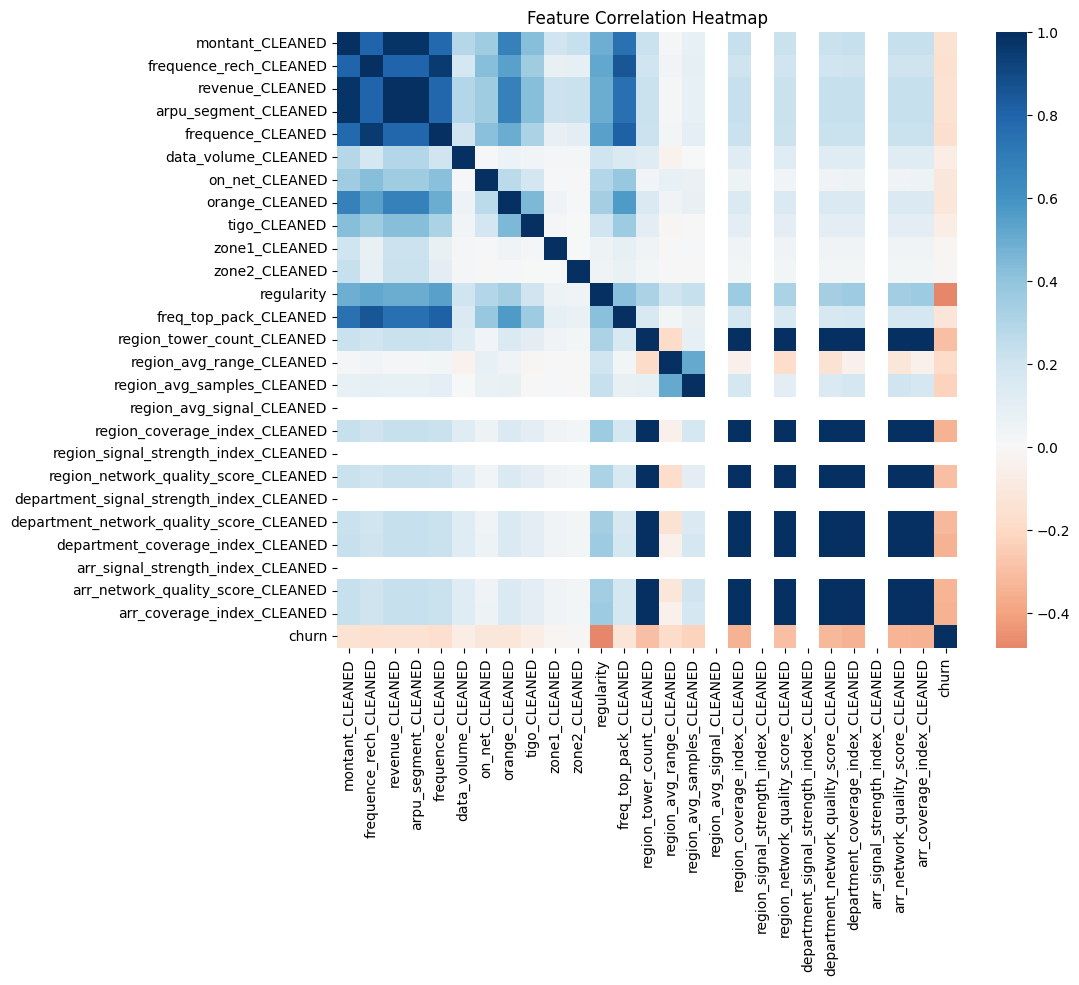

In [ ]:
corr = semi_cleaned_teleset[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, fmt=".2f", cmap='RdBu', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# Top correlates with churn
churn_corr = (
    corr['churn'].drop('churn')
    .sort_values(key=abs, ascending=False)
    .head(20)
)
tele_NAs.quantile()

fig, ax = plt.subplots(figsize=(15, 5))
colors = ['#E05252' if v > 0 else '#4A90D9' for v in churn_corr]
bars = ax.barh(churn_corr.index, churn_corr.values,
               color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax.set_title('Feature Correlation with Churn', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

In [ ]:
outliers_telecom_churn_100k = None #TODO: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
outliers_telecom_churn_100k

TBC: [Feature Engineering Recommendations](https://colab.research.google.com/drive/1vK1kOrNUVdDrvmzs2z3Kk8r-plA40xmM#scrollTo=0dvJ4a3-ug57)

# References:

> https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf

> https://en.wikipedia.org/wiki/Zen_of_Python

> https://en.wikipedia.org/wiki/Coefficient_of_variation

> https://www.merriam-webster.com/thesaurus/imputation

In [ ]:
semi_cleaned_teleset.to_csv("semi_cleaned_teleset.csv")